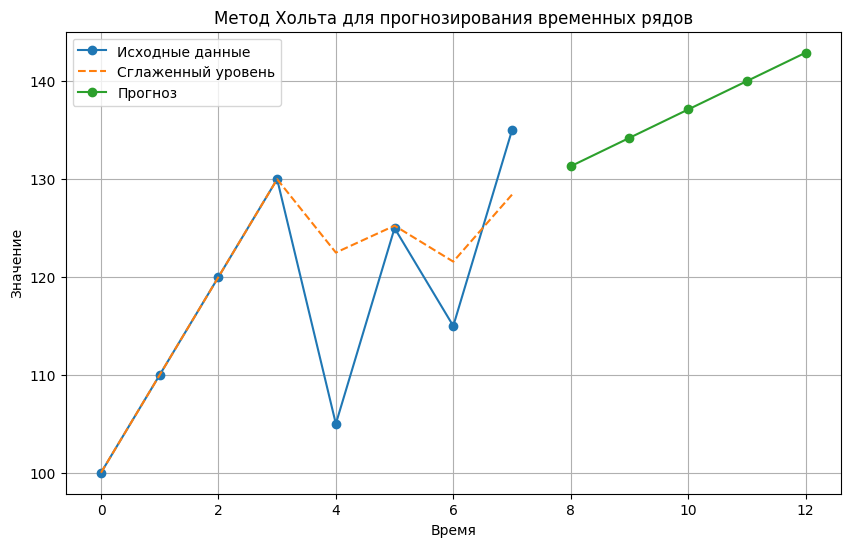

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def holt_method(y, alpha, beta, n_preds):
    l = np.zeros(len(y) + n_preds)
    b = np.zeros(len(y) + n_preds)
    l[0] = y[0]
    b[0] = y[1] - y[0]
    for t in range(1, len(y)):
        l[t] = alpha * y[t] + (1 - alpha) * (l[t-1] + b[t-1])
        b[t] = beta * (l[t] - l[t-1]) + (1 - beta) * b[t-1]
    forecast = np.zeros(n_preds)
    for h in range(1, n_preds + 1):
        forecast[h-1] = l[len(y)-1] + h * b[len(y)-1]

    return l, b, forecast

y = np.array([100, 110, 120, 130, 105, 125, 115, 135])

alpha = 0.5
beta = 0.4  
n_preds = 5 

l, b, forecast = holt_method(y, alpha, beta, n_preds)

plt.figure(figsize=(10, 6))
plt.plot(y, label='Исходные данные', marker='o')
plt.plot(l[:len(y)], label='Сглаженный уровень', linestyle='--')
plt.plot(range(len(y), len(y) + n_preds), forecast, label='Прогноз', marker='o')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.title('Метод Хольта для прогнозирования временных рядов')
plt.legend()
plt.grid()
plt.show()
